In [1]:
%%bash
git clone https://github.com/ahaberlie/SVRIMG.git > /dev/null
cd SVRIMG && pip install . > /dev/null
pip install cartopy > /dev/null
pip install scikit-learn > /dev/null
pip install tensorflow > /dev/null

Cloning into 'SVRIMG'...


# Chapter 9.5 - Image Classification

[Image classification](https://en.wikipedia.org/wiki/Computer_vision#Recognition) is the process of using [computer vision](https://en.wikipedia.org/wiki/Computer_vision) and/or [deep learning](https://en.wikipedia.org/wiki/Deep_learning) to identify the contents of a digital image. The process that can classify [handwritten digits](https://en.wikipedia.org/wiki/MNIST_database) and [general objects in images](https://en.wikipedia.org/wiki/CIFAR-10) can and has been applied to geoscience datasets. This section will discuss the history of image classification and the motivation for recent machine learning solutions built on the initial work of [Yann LeCun](https://en.wikipedia.org/wiki/Yann_LeCun) and were applied most famously in the [AlexNet](https://en.wikipedia.org/wiki/AlexNet) model.

### Chapter 9.5.1 - Initial Work and Formalization

The field of [computer vision](https://en.wikipedia.org/wiki/Computer_vision) began, not surprisingly, after the development and implementation of computing systems in the 1960s. Some of the earliest motivations and goals for artificial intelligence were based on the ability for computers to mimic the human visual system, including both the reception of visual stimuli *and* the resulting interpretationor response. Researchers drew from psychology, neuroscience, philosophy, mathematics, and computer science to attempt to better understand and formalize how humans perceive and interact with the world.

These studies led to the development of a computer vision system that can be simplified in the following steps:

1. Scene - some physical environment that the system may encounter
2. Light - electromagnetic radiation that interacts with the scene
3. Optics - components that focus or magnify light from a scene
4. Sensor - a device that detects light and converts it into an electical signal
5. Digitization - the process of converting the sensor signal into a digital representation
6. Digital image analysis - computational techniques to examine and interpret the digital image
7. Output / response - the resulting classification, decision, measurement, or other system otput.

Rudimentary computer vision techniques focused on transforming images to highlight important visual features. For example, edge detection methods can produce images that highlight boundaries and regions with strong spatial intensity gradients. These techniques relied on efficient convolution-based operations, allowing useful image transformations on the limited available hardware. Notably, the general approach of efficient convolutions has been a staple of computer vision for decades. Algorithms such as Fast Fourier Transform (https://en.wikipedia.org/wiki/Fast_Fourier_transform) and `gemm` from the [Basic Linear Algebra Subprograms (BLAS)](https://en.wikipedia.org/wiki/Basic_Linear_Algebra_Subprograms) specification are used to calculate convolutions.

**Convolution + Pooling**

For deep learning, these simple convolutions are used in concert with [pooling](https://en.wikipedia.org/wiki/Pooling_layer) or other downsampling methods to reduce the dimensionality of input images. Typically, a convolution is applied to the image abd the size of the image is reduced using a downsampling approach.

**Max pooling**

The image below represents the "max pooling" process:

    - (Left) A 6x6 input image result after applying a convolutional filter
    - (Middle) 2x2 neighborhoods extracted from the image
    - (Right) Only the max value is kept for each position (3x3).
    
The final step generalizes each 2x2 pixel neighborhood into one value. For example, the top left neighborhood has the values `-19 22 16 and -30`. The max pooling process identifies `22` as the largest value, and uses that as the top-left pixel in the resulting image.

<img src=https://upload.wikimedia.org/wikipedia/commons/b/bb/Convolutional_neural_network%2C_maxpooling.png></img>

The output from convolutions and pooling steps are typically called *feature maps*. The maps are *intermediate representations* of the initial image that emphasize important local patterns. For example, an engineered filter like an edge detector will produce a large response where strong pixel gradients occur, and those responses will appear as large values in the feature map.

### Chapter 9.5.2 - Convolutional Neural Networks

[Convolutional neural networks (CNNs)](https://en.wikipedia.org/wiki/Convolutional_neural_network) are one of the most popular and ubiquitous machine learning models. They are used for many applications, including image classification. The model consists of two main parts:

1. Convolutional layer - This layer takes an input (e.g., an image) and transform it into a compressed representation.

In deep learning, a convolutional layer transforms the input image into many feature maps through repeated convolution and pooling operations. Unlike classical computer vision approaches that use engineered filters, the [filter values (often called model weights) are initially random](https://en.wikipedia.org/wiki/Weight_initialization) and are optimized during model training. This process is typically more effective than applying many engineered filters to input images because it is data-driven.

2. Dense layers - This layer is a often a traditional [Artificial Neural Network (ANN)](https://en.wikipedia.org/wiki/Neural_network_(machine_learning) that uses the compressed image representation to learn connections between the input image and the target classifications.

Once the image is transformed into a compressed representation, the traditional machine learning model (e.g., ANN) uses those representations to learn how they connect with the target (e.g., classification). We have discussed the basis of the convolutional layer operations, but we have not talked about ANNs.

**Artificial neurons**

<img src=https://upload.wikimedia.org/wikipedia/commons/c/c6/Artificial_neuron_structure.svg></img>

An ANN is comprised of artificial neurons (shown above). Each neuron considers one or more input features, multiplies each feature by a learned weight, and the combines the weighted features with a bias term. The initial weights are typically random and are adjusted during training in a way that produces more accurate inputs. In simple terms, the weights control how strongly a feature influences the neuron's output.

The general equation for the aggregation function is shown below:

$z=\Sigma_i​w_i​x_i​+b$

Where $w_i$ are the learned weights, $x_i$ are the input features, and $b$ is the bias term.

The aggregate value `z` is then passed to an activation function:

$a = f(z)$

which produces the neuron's output.

The activation function introduces *nonlinearity* into the ANN. These functions are loosely inspired by the concept of a [threshold potential](https://en.wikipedia.org/wiki/Threshold_potential) in the human brain. For our purposes, this can be defined as the critical threshold of an input (i.e., `z`) that "activates" the function to produce some output. This allows the ANN to learn complex relationships and patterns between the input and target data. If this function was not in place, the response of the network as a whole would reduce to a linear transformation.

A very popular activation function called a [rectified linear unit (ReLU)](https://en.wikipedia.org/wiki/Rectified_linear_unit) is similar to `numpy's` `max` function:

$f(z) = max(0, z)$

which is equivalent to:

`activation = np.max([0, z])`

In other words, the value of the activation is `0` unless `z` is greater than `0`, in which case the activation is the value of `z`.

In the plot below, select `relu` in the activation dropdown and modify the weights (`w1`, `w2`) and features (`x1`, `x2`) values until you get a negative number. What is the value of `z`? What is the value of `a`?

Next, do not change those values, and instead choose `linear` as the activation function. What are `z` and `a` now?







In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown
from IPython.display import display, Markdown

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def linear(x):
    return x

activation_dict = {
    "sigmoid": sigmoid,
    "relu": relu,
    "tanh": tanh,
    "linear": linear,
}

@interact(
    x1=FloatSlider(value=1.0, min=-5, max=5, step=0.1, description='x1'),
    x2=FloatSlider(value=1.0, min=-5, max=5, step=0.1, description='x2'),
    w1=FloatSlider(value=1.0, min=-3, max=3, step=0.1, description='w1'),
    w2=FloatSlider(value=1.0, min=-3, max=3, step=0.1, description='w2'),
    b=FloatSlider(value=0.0, min=-3, max=3, step=0.1, description='bias'),
    activation=Dropdown(
        options=["sigmoid", "relu", "tanh", "linear"],
        value="relu",
        description="activation"
    )
)
def neuron_demo(x1, x2, w1, w2, b, activation):
    f = activation_dict[activation]

    # neuron calculation
    z = w1 * x1 + w2 * x2 + b
    a = f(z)

    # print values
    display(Markdown(
        f"""
### Single Neuron Calculation
- **Inputs:** $x_1 = {x1:.2f}, x_2 = {x2:.2f}$
- **Weights:** $w_1 = {w1:.2f}, w_2 = {w2:.2f}$
- **Bias:** $b = {b:.2f}$

$z = w_1x_1 + w_2x_2 + b = ({w1:.2f})({x1:.2f}) + ({w2:.2f})({x2:.2f}) + ({b:.2f}) = {z:.2f}$

$a = f(z) = {a:.2f}$
        """
    ))

    # activation plot
    xs = np.linspace(-35, 35, 500)
    ys = f(xs)

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.scatter([z], [a], s=80)
    plt.axvline(z, linestyle='--')
    plt.title(f"Activation Response: {activation}")
    plt.xlabel("z")
    plt.ylabel("f(z)")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='x1', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

**Activation response example**

Download the `SVRIMG` dataset:

In [3]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

Examine a radar image:

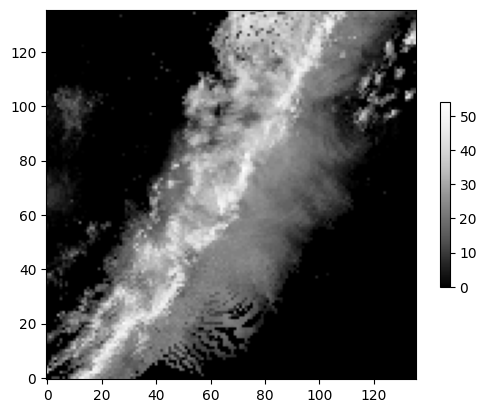

In [4]:
plt.imshow(x_train[56, :, :].squeeze(), cmap='Greys_r', origin='lower')
plt.colorbar(shrink=0.5)

Extract a 5x5 max pooling feature from:

1. Bright location (~50 dBZ)
2. Darker location (~20 dBZ)
3. Black location (~0 dBZ)

Max pool results [np.uint8(49), np.uint8(25), np.uint8(9)]


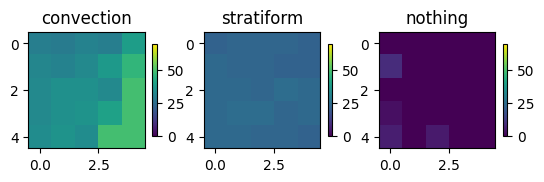

In [5]:
w = x_train[56, 60:65, 60:65].squeeze()
g = x_train[56, 40:45, 70:75:].squeeze()
b = x_train[56, 100:105, 20:25].squeeze()

max_pool = []

for i, (title, val) in enumerate(zip(['convection', 'stratiform', 'nothing'], [w, g, b])):

    ax = plt.subplot(1, 3, i+1)
    ax.set_title(title)
    mmp = ax.imshow(val, vmin=0, vmax=70)
    plt.colorbar(mmp, ax=ax, shrink=0.25)

    max_pool.append(np.max(val))

print("Max pool results", max_pool)

Now apply the widget example above to these data for the purposes of signaling that a convective core (high dBZ values) exists in one of these 5x5 neighborhoods via the max pooling result:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

# Example patches
w = x_train[56, 60:65, 60:65].squeeze()      # high-value region
g = x_train[56, 40:45, 70:75].squeeze()      # medium-value region
b = x_train[56, 100:105, 20:25].squeeze()    # low-value region

patches = {
    "convection": w,
    "stratiform": g,
    "nothing": b,
}

def relu(x):
    return np.maximum(0, x)

def pooling_activation_demo(threshold=40.0, weight=1.0, bias=0.0):
    names = list(patches.keys())
    vals = list(patches.values())

    pooled = [np.max(v) for v in vals]
    z_vals = [weight * p + bias - threshold for p in pooled]
    a_vals = [relu(z) for z in z_vals]

    plt.close("all")
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    for i, (name, patch, p, z, a) in enumerate(zip(names, vals, pooled, z_vals, a_vals)):
        ax = axes[0, i]
        mmp = ax.imshow(patch, vmin=0, vmax=70)
        ax.set_title(f"{name}\nmax pool = {p:.2f}")
        plt.colorbar(mmp, ax=ax, shrink=0.7)

        ax2 = axes[1, i]
        bars = ax2.bar(["max pool", "z", "ReLU(z)"], [p, z, a])
        ax2.axhline(0, linestyle="--")
        ax2.set_ylim(min(-10, min(z_vals) - 5), max(max(pooled), max(a_vals), max(z_vals)) + 5)
        ax2.set_title(f"{name} response")

    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"""
### Max pooling and activation response

For each patch:

$ \\text{{max pool}} = \\max(\\text{{patch}}) $

$ z = w \\cdot (\\text{{max pool}}) + b - \\text{{threshold}} $

$ a = \\mathrm{{ReLU}}(z) = \\max(0, z) $

Current settings:
- **threshold** = {threshold:.2f}
- **weight** = {weight:.2f}
- **bias** = {bias:.2f}

This demonstrates that only the patch with a sufficiently large max-pooled value should produce a positive activation.
"""
    ))

    for name, p, z, a in zip(names, pooled, z_vals, a_vals):
        print(f"{name:12s}  max pool = {p:6.2f}   z = {z:7.2f}   ReLU(z) = {a:7.2f}")

widgets.interact(
    pooling_activation_demo,
    threshold=widgets.FloatSlider(value=40.0, min=0.0, max=70.0, step=1.0, description="threshold"),
    weight=widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1, description="weight"),
    bias=widgets.FloatSlider(value=0.0, min=-20.0, max=20.0, step=1.0, description="bias"),
);

interactive(children=(FloatSlider(value=40.0, description='threshold', max=70.0, step=1.0), FloatSlider(value=…

### Chapter 9.5.3 - Training a CNN

We first should make sure that we gave access to a GPU. If the list is empty, you forgot to switch to T4 OR you have run out of time / no GPUs are available. If it is the first case, read the directions above. You can move forward with a CPU only, but it will be slower.

In [7]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices(device_type="GPU")

gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Download SVRIMG again just in case you accidentally modified it above:

In [8]:
from svrimg.utils.get_images import get_example_data

(x_train, y_train) = get_example_data('training', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_val, y_val) = get_example_data('validation', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")
(x_test, y_test) = get_example_data('testing', data_dir=".", url="https://nimbus.niu.edu/svrimg/data/classifications/")

**Preprocessing steps**

You typically want to "normalize" your image data first, as this has been found to improve the training process and results. In this case, we do a quick "min max" normalization:

In [9]:
minimum = np.min(x_train)
maximum = np.max(x_train)

print(maximum, minimum)

x_train = (x_train - minimum) / (maximum - minimum)
x_val = (x_val - minimum) / (maximum - minimum)
x_test = (x_test - minimum) / (maximum - minimum)

print(np.max(x_train), np.min(x_train))

74 0
1.0 0.0


We also need to reshape our label data to have 6 array positions that correspond to a label.

For example

```[0]``` -> ```[1, 0, 0, 0, 0, 0]```

```[5]``` -> ```[0, 0, 0, 0, 0, 1]```

This is needed to calculate one of our "loss" functions. We will talk about this later.

In [10]:
from tensorflow import keras

num_classes = 6

y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print(y_train[:10])

y_train shape: (1331, 6)
y_val shape: (110, 6)
y_test shape: (300, 6)
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]


For the first 10 transformed labels, the first 9 have a "1." in index 1 (QLCS), and the last one has a "1." in index 0 (Cellular).

We will be using the ```keras.Sequential``` module to create our CNN architecture.

There are many different shapes and sizes of CNNs, but they all include a convolutional layer, a pooling layer, and a dense layer.

1. convolutional layer: this automatically extracts features from the input image using tunable filters (kernels). These filters transform the image in ways to highlight the relevant spatial information.

2. pooling layer: after the convolution is applied, this layer merges the results from multiple pixels to get spatially-generalized results. CNNs require a steady reduction in image size until they become "tabular".

3. dense layer: this is a normal neural network (MLP) layer that takes the transformed input from the preceding layers as if they were tabular data passed in by the user.

The simplest version of our model is below:

In [11]:
from tensorflow.keras import layers

input_shape = (136, 136, 1)

model = keras.Sequential(
    [
        keras.Input(shape=(136, 136, 1)),
        layers.Conv2D(32, kernel_size=(3, 3)),
        layers.MaxPooling2D(pool_size=(3, 3)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 134, 134, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,931,078 (30.25 MB)

 Trainable params: 7,931,078 (30.25 MB)

 Non-trainable params: 0 (0.00 B)

Let's try training it! If you are not on a GPU, it will take quite awhile.

What you are seeing is the dataset being provided to the model for training and then tuning the neural networks and convolutional layers to maximize the accuracy of the model. Each epoch is passing the data to the model and retraining it based on its state at the end of the previous epoch.

In [12]:
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-4), metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val))

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6379 - loss: 1.0248 - val_accuracy: 0.7545 - val_loss: 0.9120
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7453 - loss: 0.7401 - val_accuracy: 0.7455 - val_loss: 0.7835
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8017 - loss: 0.6236 - val_accuracy: 0.7909 - val_loss: 0.7098
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8212 - loss: 0.5491 - val_accuracy: 0.7727 - val_loss: 0.7361
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8347 - loss: 0.4946 - val_accuracy: 0.7909 - val_loss: 0.7061
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8527 - loss: 0.4304 - val_accuracy: 0.7727 - val_loss: 0.7132
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8700 - loss: 0.3900 - val_accuracy: 0.7364 - val_loss: 0.8509
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8805 - loss: 0.3570 - val_accuracy: 0.7909 - v

Wow! An accuracy of over 90%! That is fantastic. Right? Right?

The ```accuracy``` metric reported above is the *training* accuracy.

The more important accuracy to examine is the ```val_accuracy```, which attempts to estimate the generalizability of the model (*validation* accuracy).

We can plot how these two different accuracies change epoch to epoch.

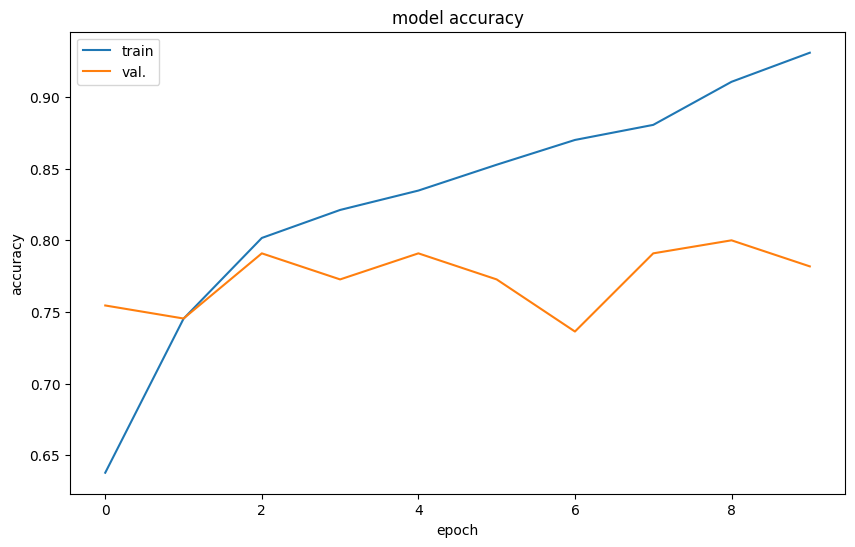

In [13]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = 10, 6

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val.'], loc='upper left')
plt.show()

In a model with good generalizability, the train and validation accuracy would be exactly the same--in other words, the trained model can handle new data just as well as it handles the training data.

What is your interpretation of the results above?

**Ways to improve performance**

If we suspect the model is not complex enough to handle the dataset, we may need to increase its complexity.

Before we do that, we can test out some specific approaches.

1. Dropout - this approach randomly removes data from pixels in convolution results during training steps. The result of this is similar to bootstrapping, as it requires the model to consider a more diverse set of pixels and not just a few of the same pixels.

2. Activations - this approach decides what pixel values from convolution results are 'significant' and this is derived from the training steps. It will 'zero out' pixels that are not significant, and this can help the model focus less on noise and more on more pertinent features. One popular activation is a Rectified Linear Unit (ReLU).

3. Data augmentation - this approach applies random transformations to the input data like rotations, zooms, etc. This simulates having a larger set of data by assuming that "missing data" are just slightly different versions of the labeled data. We will explore this in more detail below.

4. Learning rate - if your model learns too quickly, it may "jump to conclusions". However, if it learns too slowly, it may never create a useful model. This requires finding a good balance.

5. Batch size - like with bootstrapping, it is sometimes useful to withhold data from the model during certain training steps. You need to provide enough data to learn something, but not too much where the model just memorizes the training dataset.

1 and 2 can be directly applied to the model definition:

In [14]:
model = keras.Sequential(
    [
        keras.Input(shape=(136, 136, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"), # ReLu activation
        layers.SpatialDropout2D(0.3), # Dropout, where 0.3 is "30% of pixels are randomly zeroed out during each step"
        layers.MaxPooling2D(pool_size=(3, 3)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 134, 134, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 134, 134, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,931,078 (30.25 MB)

 Trainable params: 7,931,078 (30.25 MB)

 Non-trainable params: 0 (0.00 B)

Let's try again!

In [15]:
epochs = 10

model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-4), metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val))

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.6213 - loss: 1.0940 - val_accuracy: 0.7000 - val_loss: 0.9232
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7325 - loss: 0.8039 - val_accuracy: 0.7364 - val_loss: 0.8399
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7408 - loss: 0.7330 - val_accuracy: 0.7727 - val_loss: 0.7907
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7716 - loss: 0.6558 - val_accuracy: 0.7364 - val_loss: 0.7794
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8047 - loss: 0.6100 - val_accuracy: 0.7727 - val_loss: 0.7609
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8144 - loss: 0.5551 - val_accuracy: 0.7364 - val_loss: 0.7584
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8370 - loss: 0.5135 - val_accuracy: 0.7818 - val_loss: 0.7441
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8512 - loss: 0.4811 - val_accuracy: 0.7364 - v

And the results:

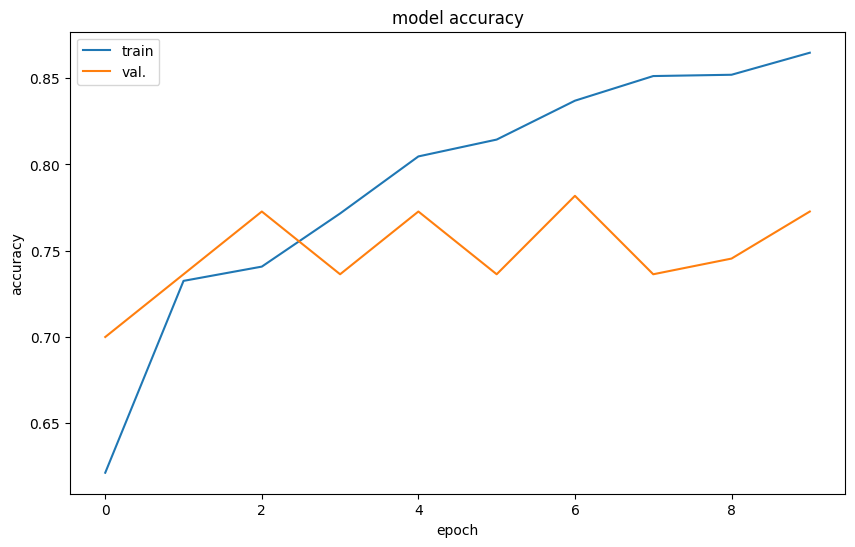

In [16]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = 10, 6

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val.'], loc='upper left')
plt.show()

Both the training and validation accuracy decreased due to the purposeful removal of pixels randomly during the training process. This does not tell us much about the final result, as it may take more steps to find the optimal solution.

**Data Augmentation**

We will use the ImageDataGenerator feature in tensorflow to provide slightly modified versions of our labeled data to the model training process. But, the training and validation lines still significantly diverge, suggesting that the model is overfitting to the training data.

First, pick a sample to "augment" so we can visualize the process:

<Axes: xlabel='km', ylabel='km'>

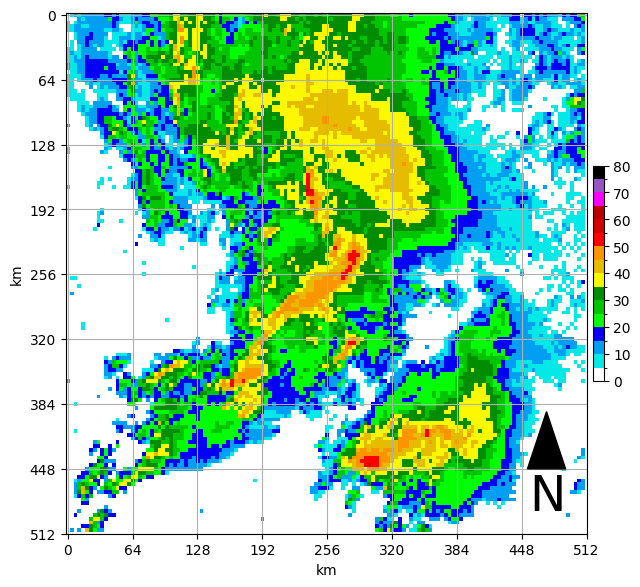

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = 8, 8

from svrimg.mapping.map_helper import draw_box_plot

sample = x_test[110]

ax = plt.subplot(1,1,1)
draw_box_plot(ax, sample * ((maximum - minimum) + minimum))

Next we will define our ImageDataGenerator with the specified ranges of random modifications and apply those transformations to our sample image.

### Your turn

Try to find a combination of transformations that result in a diverse result, while also containing samples that are physically reasonable.

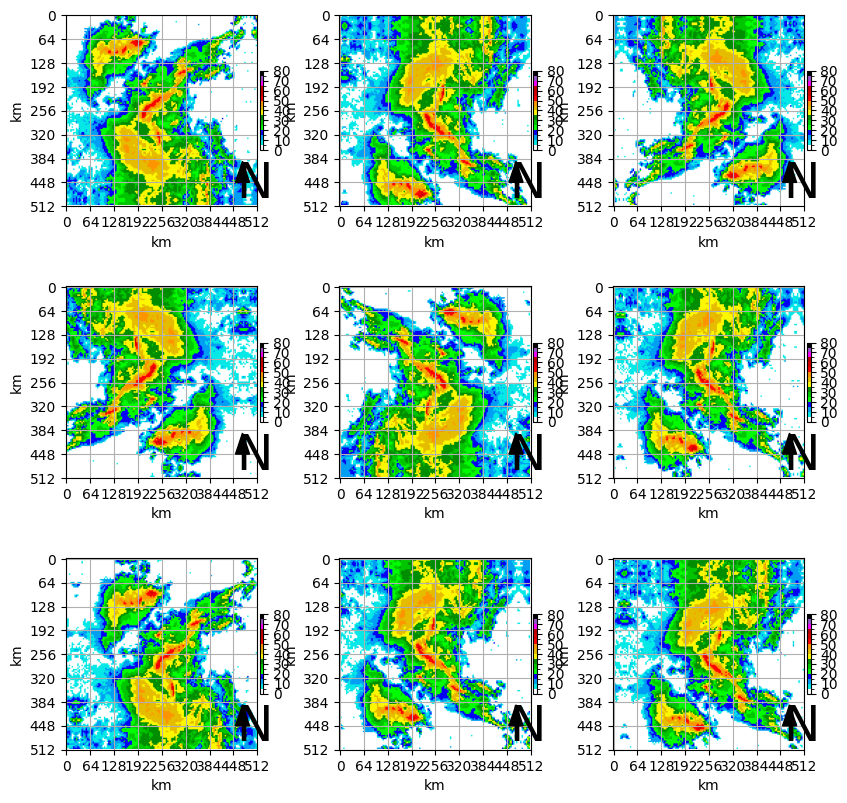

In [18]:
plt.rcParams['figure.figsize'] = 10, 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=0.1,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             shear_range=0.1,
                             zoom_range=0.1,
                             horizontal_flip=True,
                             vertical_flip=True,
                             fill_mode='reflect')

# simulate having an array of images
samples = np.expand_dims(sample, 0)

vis_size = 9

for ax_num, batch in enumerate(datagen.flow(samples, batch_size=1)):

    if ax_num == vis_size:
        break
    else:
        ax = plt.subplot(3, 3, ax_num+1)
        draw_box_plot(ax, batch[0].squeeze()*80)

This is simulating a thunderstorm cluster with a similar shape but with a different orientation.

To train using the image generator we created requires only a small addition to the training code:

In [19]:
epochs = 10

# we are trying to maximize both accuracy and confidence with categorical crossentropy
# the learning rate can be increased or decreased if needed.
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-5), metrics=["accuracy"])

# each training step receives ```batch_size``` augmented examples for training.
history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                                 epochs=epochs, validation_data=(x_val, y_val))

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.5567 - loss: 1.2062 - val_accuracy: 0.8000 - val_loss: 0.7024
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5815 - loss: 1.0725 - val_accuracy: 0.7909 - val_loss: 0.6813
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6056 - loss: 1.0695 - val_accuracy: 0.7545 - val_loss: 0.6658
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6251 - loss: 1.0030 - val_accuracy: 0.7636 - val_loss: 0.6641
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6221 - loss: 1.0037 - val_accuracy: 0.7909 - val_loss: 0.6442
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6319 - loss: 0.9817 - val_accuracy: 0.7727 - val_loss: 0.6742
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6349 - loss: 0.9889 - val_accuracy: 0.7818 - val_loss: 0.6464
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6454 - loss: 0.9758 - val_accuracy: 0.7727 - 

Your Turn: How did it do?

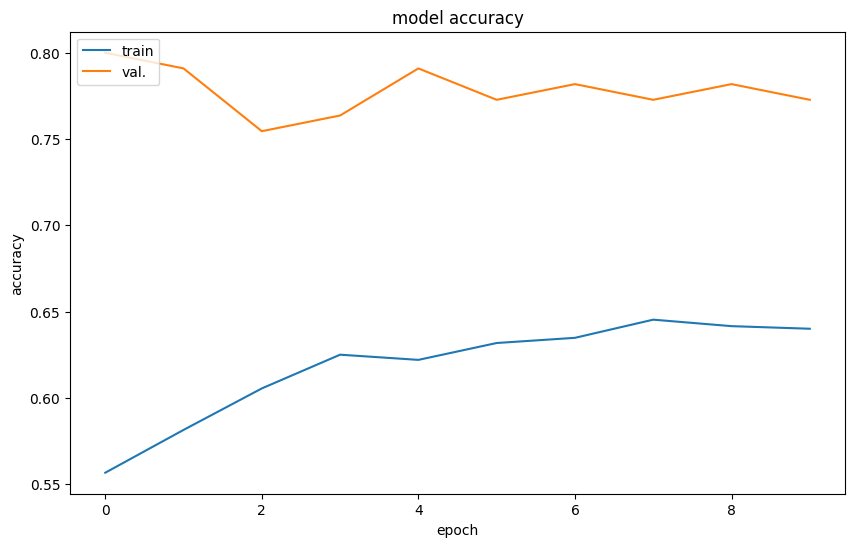

In [20]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = 10, 6

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val.'], loc='upper left')
plt.show()

### Chapter 9.5.5 - Model weights

The purpose of the convolutional layer is to perform a "smart" feature extraction process that is data driven.

We can peak into the model to see what is going on. First, we can look at the model "weights". These will correspond to the summary table of the CNN above.


In [21]:
weights = model.get_weights()

for w in weights:
    print(w.shape)

(3, 3, 1, 32)
(32,)
(61952, 128)
(128,)
(128, 6)
(6,)


If we focus on the first set of weights, we see that they have the dimensions ```(3, 3, 1, 32)``` which means there are 32 weights, and each weight has the dimensions of ```(3, 3, 1)```

We can view any given weight by choosing what layer we are going to examine, and then which one of the weights we want to look at in that layer.

For example, the first layer, 10th weight. Does this look like anything we have dealt with before?

In [22]:
w0 = weights[0][:, :, :, 9].squeeze() # remove size 1 dim

print(w0)
print("weight shape is", w0.shape)

[[-0.12400948 -0.01722287  0.01742088]
 [ 0.14529574  0.07023787 -0.04028447]
 [ 0.01201739 -0.10779794 -0.08515602]]
weight shape is (3, 3)


Another name for a weight is a convolutional kernel. As we discussed last time, this is an image transformation technique that selectively sums up multiplications of neighborhood pixels for a particular detection purpose.

We can examine some popular kernels and then this kernel for convolving one of our input images:

1. Identity kernel
2. Edge detector
3. Blur
4. Sharpen

In [23]:
id_k = [[0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]]

edge_k = [[  -1, 0,  1],
          [ -10, 0, 10],
          [  -1, 0,  1]]

blur_k = [[1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9]]

sharpen_k = [[ 0, -1,  0],
             [-1,  5, -1],
             [ 0, -1,  0]]

gaussian_k = [[1/16, 2/16, 1/16],
              [2/16, 4/16, 2/16],
              [1/16, 2/16, 1/16]]

We will make it easier than last time and use a convolve function from scipy.

Each time you run the following code, a new image will pop up.

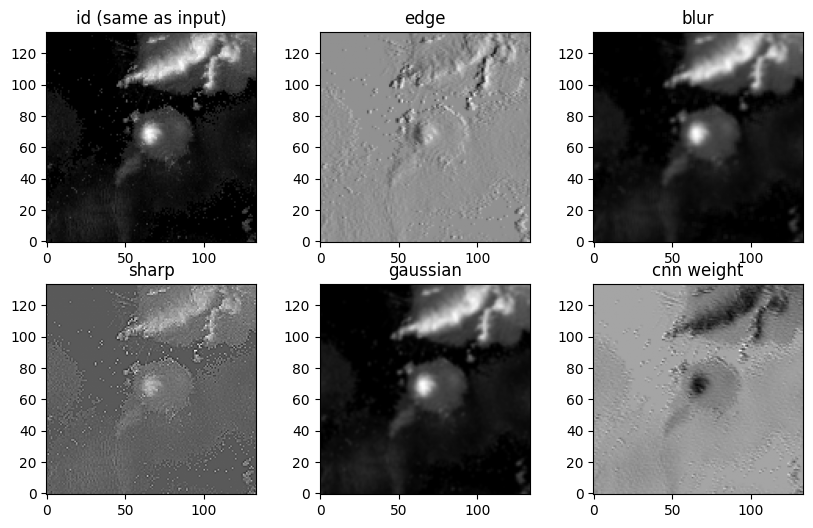

In [24]:
from scipy import signal

filters = [id_k, edge_k, blur_k, sharpen_k, gaussian_k, w0]
labels = ['id (same as input)', 'edge', 'blur', 'sharp', 'gaussian', 'cnn weight']

sample = x_test[np.random.randint(0, x_test.shape[0])]

for ax_num, (k, l) in enumerate(zip(filters, labels)):

    conva = signal.convolve(sample.squeeze(), k, mode='valid', method='direct')
    ax = plt.subplot(2, 3, ax_num+1)
    mmp=ax.imshow(conva, cmap='gray', origin='lower')
    ax.set_title(l)

It is sometimes difficult to assess what each filter in the convolutional layer is doing, as these can be tuned for highly non-linear connections within the model.

We can visualize all of the weights in a layer. Each weight is applied to a copy of the input and then the resulting convolution is passed to the next layer in the model.

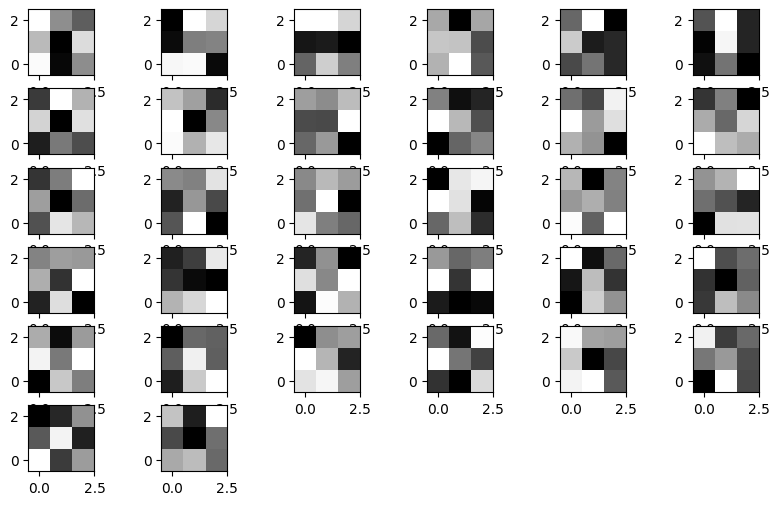

In [25]:
for i in range(32):
    ax = plt.subplot(6, 6, i+1)
    ax.imshow(weights[0][:,:, 0, i], cmap='gray', origin='lower')

We can also visualize the results of each convolution for a given sample by creating a model that is "cut off" at a particular layer. In other words, instead of outputing a prediction, we want to output an intermediate step.

In [26]:
from tensorflow.keras.models import Model

# grab the first layer which is the input layer
input = model.get_layer(index=0).input

# grab first layer after the input layer
# this is the first convolutional layer
conv_layer1 = model.get_layer(index=0).output

# create a new "model" that only has the input and
# layers up to and including "index"
cutoff1 = Model(input, conv_layer1)

cutoff1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 136, 136, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 134, 134, 32)   │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

We then simply ask the model to provide a "prediction" based on the input data:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
(1, 134, 134, 32)


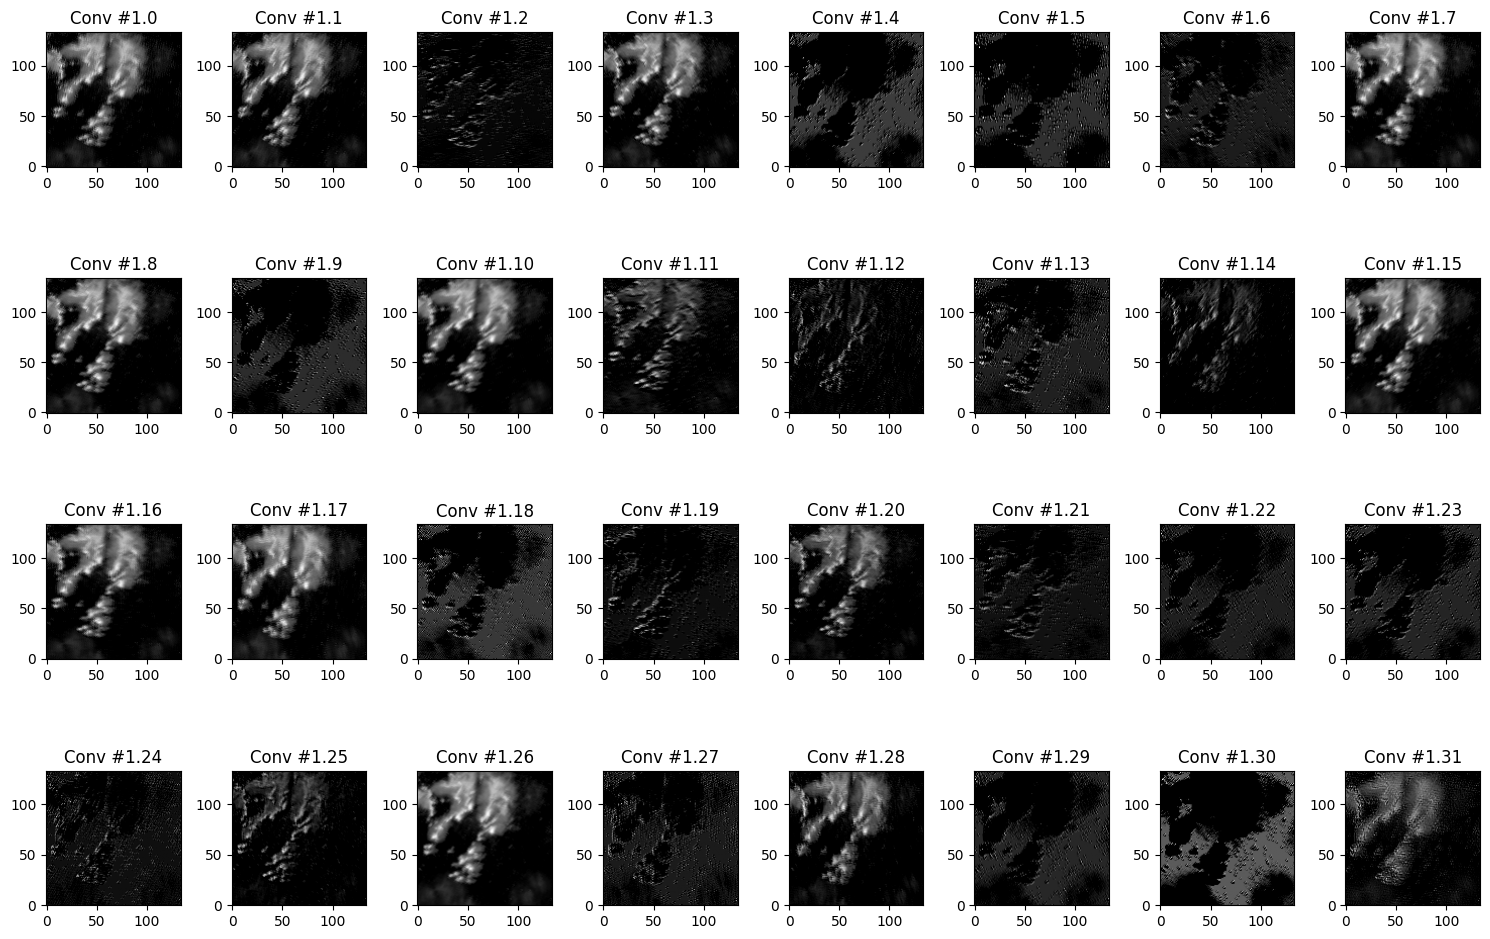

In [27]:
plt.rcParams['figure.figsize'] = 15, 10

sample_ix = np.random.randint(0, x_test.shape[0])
samples_sim = np.expand_dims(x_test[sample_ix], axis=0)

conv_result = cutoff1.predict(samples_sim)

print(conv_result.shape)

for i in range(32):
    ax = plt.subplot(4, 8, i+1)
    ax.set_title("Conv #1.{}".format(i))
    ax.imshow(conv_result[0, :, :, i], cmap='gray', origin='lower')

plt.tight_layout()

Finally, examine what the last two dense layers look like

In [28]:
# grab the first layer which is the input layer
input = model.get_layer(index=0).input

# grab first layer after the input layer
# this is the first convolutional layer
dense_layer1 = model.get_layer(index=-2).output

# create a new "model" that only has the input and
# layers up to and including "index"
cutoff3 = Model(input, dense_layer1)

cutoff3.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 136, 136, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 134, 134, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 134, 134, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,930,304 (30.25 MB)

 Trainable params: 7,930,304 (30.25 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# grab the first layer which is the input layer
input = model.get_layer(index=0).input

# grab first layer after the input layer
# this is the first convolutional layer
dense_layer2 = model.get_layer(index=-1).output

# create a new "model" that only has the input and
# layers up to and including "index"
cutoff4 = Model(input, dense_layer2)

cutoff4.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 136, 136, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 134, 134, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 134, 134, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,931,078 (30.25 MB)

 Trainable params: 7,931,078 (30.25 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


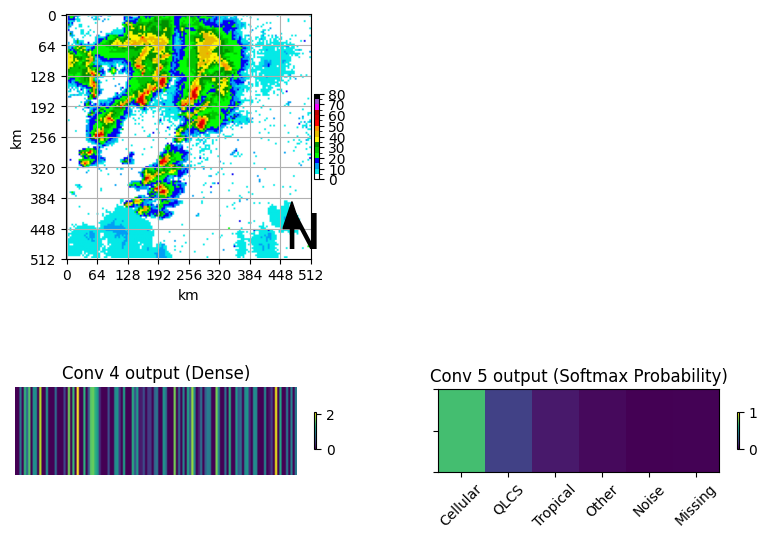

In [30]:
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10

lookup = {0:'Cellular', 1:'QLCS', 2:'Tropical', 3:'Other', 4:'Noise', 5:'Missing'}

dense_1_result = cutoff3.predict(samples_sim)
dense_2_result = cutoff4.predict(samples_sim)

ax = plt.subplot(2,2,1)
draw_box_plot(ax, samples_sim[0,:,:,0]*80)

ax = plt.subplot(2,2,3)
mmp = ax.imshow(dense_1_result, aspect=40)
plt.colorbar(mmp, ax=ax, shrink=0.15)
ax.set_title("Conv 4 output (Dense)")
ax.axis('off')

ax = plt.subplot(2,2,4)
mmp = ax.imshow(dense_2_result, aspect=1.75, vmin=0, vmax=1)
ax.set_title("Conv 5 output (Softmax Probability)")
ax.set_yticklabels([])
ax.set_xticks(range(6), labels=list(lookup.values()), fontsize=10, rotation=45)
plt.colorbar(mmp, ax=ax, shrink=0.15)